# PDF Quality Audit
**CPIE — Week 2, Step 3**

Six checks per document. No pipeline code until every document has a confirmed action.

**Actions per document:** Include / Include with fixes / Replace with primary source / Drop from v1

In [1]:
import sys
import re
from pathlib import Path
import fitz  # PyMuPDF
import pandas as pd
from IPython.display import display

RAW_DIR = Path('../data/raw')
pdfs = sorted(RAW_DIR.glob('*.pdf'))
print(f'Found {len(pdfs)} PDFs:')
for p in pdfs:
    print(f'  {p.name}')

Found 12 PDFs:
  739682_ESO_Beyond2030_Report_2024_PRINT.pdf
  boes-climate-related-financial-disclosure-2024.pdf
  climate-change-possible-macroeconomic-implications.pdf
  key-elements-2021-biennial-exploratory-scenario-financial-risks-climate-change.pdf
  measuring-climate-related-financial-risks-using-scenario-analysis.pdf
  Progress-in-reducing-emissions-2024-Report-to-Parliament-Web.pdf
  Progress-in-reducing-emissions-2025-report-to-Parliament.pdf
  results-of-the-2021-climate-biennial-exploratory-scenario.pdf
  Smart-Secure-Electricity-Systems-Implementing-the-load-control-licensing-regime-consultation.pdf
  The-Seventh-Carbon-Budget.pdf
  WorldEnergyOutlook2025.pdf
  zev-mandate-consultation-summary-of-responses-and-joint-government-response.pdf


In [2]:
import torch
print(torch.cuda.is_available())  # True = GPU available
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

True
NVIDIA GeForce RTX 4050 Laptop GPU


## Institution mapping
Assign each PDF to institution and document type based on filename.

In [3]:
# Manual mapping — update if filenames change
DOC_META = {
    '739682_ESO_Beyond2030_Report_2024_PRINT.pdf': {
        'institution': 'National Grid ESO',
        'doc_type': 'technical_report',
        'jurisdiction': 'UK',
        'chunking_strategy': 'section',
    },
    'Progress-in-reducing-emissions-2024-Report-to-Parliament-Web.pdf': {
        'institution': 'CCC',
        'doc_type': 'statutory_report',
        'jurisdiction': 'UK',
        'chunking_strategy': 'section',
    },
    'Progress-in-reducing-emissions-2025-report-to-Parliament.pdf': {
        'institution': 'CCC',
        'doc_type': 'statutory_report',
        'jurisdiction': 'UK',
        'chunking_strategy': 'section',
    },
    'Smart-Secure-Electricity-Systems-Implementing-the-load-control-licensing-regime-consultation.pdf': {
        'institution': 'Ofgem',
        'doc_type': 'consultation',
        'jurisdiction': 'UK',
        'chunking_strategy': 'numbered_paragraph',
    },
    'The-Seventh-Carbon-Budget.pdf': {
        'institution': 'CCC',
        'doc_type': 'statutory_report',
        'jurisdiction': 'UK',
        'chunking_strategy': 'section',
    },
    'WorldEnergyOutlook2025.pdf': {
        'institution': 'IEA',
        'doc_type': 'outlook_report',
        'jurisdiction': 'Global',
        'chunking_strategy': 'section_exec_summary_separate',
    },
    'boes-climate-related-financial-disclosure-2024.pdf': {
        'institution': 'BoE',
        'doc_type': 'disclosure_report',
        'jurisdiction': 'UK',
        'chunking_strategy': 'section_heading',
    },
    'climate-change-possible-macroeconomic-implications.pdf': {
        'institution': 'BoE',
        'doc_type': 'discussion_paper',
        'jurisdiction': 'UK',
        'chunking_strategy': 'section_heading',
    },
    'key-elements-2021-biennial-exploratory-scenario-financial-risks-climate-change.pdf': {
        'institution': 'FCA/PRA',
        'doc_type': 'scenario_analysis',
        'jurisdiction': 'UK',
        'chunking_strategy': 'section_heading',
    },
    'measuring-climate-related-financial-risks-using-scenario-analysis.pdf': {
        'institution': 'FCA/PRA',
        'doc_type': 'methodology_paper',
        'jurisdiction': 'UK',
        'chunking_strategy': 'section_heading',
    },
    'results-of-the-2021-climate-biennial-exploratory-scenario.pdf': {
        'institution': 'FCA/PRA',
        'doc_type': 'results_report',
        'jurisdiction': 'UK',
        'chunking_strategy': 'section_heading',
    },
    'zev-mandate-consultation-summary-of-responses-and-joint-government-response.pdf': {
        'institution': 'DESNZ',
        'doc_type': 'consultation_response',
        'jurisdiction': 'UK',
        'chunking_strategy': 'page_overlap',
    },
}
print('Mapping complete.')

Mapping complete.


## Check 1 — Extractability
Flag any document where >10% of pages return empty strings.

In [4]:
def check_extractability(pdf_path: Path) -> dict:
    doc = fitz.open(str(pdf_path))
    n_pages = len(doc)
    empty_pages = []
    for i, page in enumerate(doc):
        text = page.get_text('text').strip()
        if not text:
            empty_pages.append(i + 1)
    doc.close()
    pct_empty = len(empty_pages) / n_pages if n_pages else 0
    return {
        'pages': n_pages,
        'empty_pages': len(empty_pages),
        'pct_empty': round(pct_empty, 3),
        'extractable': pct_empty <= 0.10,
        'empty_page_list': empty_pages[:10],  # first 10 for inspection
    }

extractability = {}
for pdf in pdfs:
    result = check_extractability(pdf)
    extractability[pdf.name] = result
    flag = '✓' if result['extractable'] else '✗ NEEDS OCR'
    print(f"{flag}  {pdf.name[:60]:<60} "
          f"{result['pages']} pages, {result['pct_empty']:.0%} empty")

✓  739682_ESO_Beyond2030_Report_2024_PRINT.pdf                  198 pages, 0% empty
✓  boes-climate-related-financial-disclosure-2024.pdf           56 pages, 0% empty
✓  climate-change-possible-macroeconomic-implications.pdf       34 pages, 0% empty
✓  key-elements-2021-biennial-exploratory-scenario-financial-ri 52 pages, 0% empty
✓  measuring-climate-related-financial-risks-using-scenario-ana 41 pages, 0% empty
✓  Progress-in-reducing-emissions-2024-Report-to-Parliament-Web 102 pages, 0% empty
✓  Progress-in-reducing-emissions-2025-report-to-Parliament.pdf 134 pages, 4% empty
✓  results-of-the-2021-climate-biennial-exploratory-scenario.pd 86 pages, 0% empty
✓  Smart-Secure-Electricity-Systems-Implementing-the-load-contr 69 pages, 0% empty
✓  The-Seventh-Carbon-Budget.pdf                                394 pages, 3% empty
✓  WorldEnergyOutlook2025.pdf                                   519 pages, 2% empty
✓  zev-mandate-consultation-summary-of-responses-and-joint-gove 46 pages, 0% empty

## Check 2 — Layout quality
Spot-check 3 pages per document. Look for footnote/header bleed and coherence.

In [5]:
def get_spot_pages(n_pages: int) -> list[int]:
    """Return 3 representative 0-indexed page numbers."""
    if n_pages <= 3:
        return list(range(n_pages))
    return [1, n_pages // 2, n_pages - 2]  # near start, middle, near end


def check_layout(pdf_path: Path, n_chars: int = 600) -> dict:
    doc = fitz.open(str(pdf_path))
    n_pages = len(doc)
    spot = get_spot_pages(n_pages)
    excerpts = {}
    for idx in spot:
        text = doc[idx].get_text('text').strip()
        excerpts[idx + 1] = text[:n_chars]  # page number (1-indexed)
    doc.close()
    return {'spot_pages': spot, 'excerpts': excerpts}


print("Spot-check excerpts (first 600 chars per page)\n" + "=" * 60)
layout_results = {}
for pdf in pdfs:
    result = check_layout(pdf)
    layout_results[pdf.name] = result
    print(f"\n{'─'*60}")
    print(f"FILE: {pdf.name}")
    for pg, text in result['excerpts'].items():
        print(f"  [Page {pg}]\n{text[:300]}\n")

Spot-check excerpts (first 600 chars per page)

────────────────────────────────────────────────────────────
FILE: 739682_ESO_Beyond2030_Report_2024_PRINT.pdf
  [Page 2]
Navigation
Download a pdf
To download a full copy of this report go to  
www.nationalgrideso.com/future-energy/beyond2030
Text Links 
Click  highlighted  orange text to 
navigate to an external link. Or to jump 
to another section of the document
Return to contents
From here you can navigate to any 

  [Page 100]
Warrington
Manchester
Blackpool
Liverpool
Beyond 2030  /  Regional Blueprints  /  North West  100
Beyond 2030  /  Regional Blueprints  /  North West  100
North West
Category
Key
New offshore network 
infrastructure
New onshore network 
infrastructure 
Voltage increase on network 
Existing network up

  [Page 197]
National 
Grid ESO
Email  
ESO
National 
Grid ESO
@National 
GridESO


────────────────────────────────────────────────────────────
FILE: boes-climate-related-financial-disclosure-2024.pdf
  [Page 2]


### Layout quality assessment
After reading the excerpts above, fill in this dict manually.

In [6]:
# Fill in after reading excerpts above.
# Values: True / False / 'partial'
LAYOUT_CLEAN = {
    '739682_ESO_Beyond2030_Report_2024_PRINT.pdf': False,
    'Progress-in-reducing-emissions-2024-Report-to-Parliament-Web.pdf': 'partial',
    'Progress-in-reducing-emissions-2025-report-to-Parliament.pdf': 'partial',
    'Smart-Secure-Electricity-Systems-Implementing-the-load-control-licensing-regime-consultation.pdf': 'partial',
    'The-Seventh-Carbon-Budget.pdf': True,
    'WorldEnergyOutlook2025.pdf': True,
    'boes-climate-related-financial-disclosure-2024.pdf': True,
    'climate-change-possible-macroeconomic-implications.pdf': True,
    'key-elements-2021-biennial-exploratory-scenario-financial-risks-climate-change.pdf': True,
    'measuring-climate-related-financial-risks-using-scenario-analysis.pdf': True,
    'results-of-the-2021-climate-biennial-exploratory-scenario.pdf': True,
    'zev-mandate-consultation-summary-of-responses-and-joint-government-response.pdf': True,
}
print("Update LAYOUT_CLEAN after reading excerpts above.")

Update LAYOUT_CLEAN after reading excerpts above.


## Check 3 — Structural markers
Numbered paragraphs (Ofgem), section headings (FCA), chapter titles (DESNZ/IPCC/IEA).

In [7]:
STRUCTURAL_PATTERNS = {
    'numbered_paragraph': re.compile(r'^\d+\.\d+', re.MULTILINE),   # 3.14, 4.1 etc.
    'section_heading': re.compile(r'^\d+\.?\s+[A-Z][A-Za-z ]{3,}', re.MULTILINE),
    'chapter_title': re.compile(r'^(Chapter|Section|Part)\s+\d+', re.MULTILINE | re.IGNORECASE),
    'executive_summary': re.compile(r'Executive Summary', re.IGNORECASE),
}


def check_structural_markers(pdf_path: Path) -> dict:
    doc = fitz.open(str(pdf_path))
    full_text = '\n'.join(page.get_text('text') for page in doc)
    doc.close()
    return {
        name: bool(pattern.search(full_text))
        for name, pattern in STRUCTURAL_PATTERNS.items()
    }


structural = {}
print(f"{'Document':<55} {'Num¶':<6} {'SecHdr':<8} {'Chapter':<9} {'ExecSum'}")
print('─' * 85)
for pdf in pdfs:
    r = check_structural_markers(pdf)
    structural[pdf.name] = r
    row = '  '.join('✓' if v else '✗' for v in r.values())
    print(f"{pdf.name[:54]:<55} {row}")

Document                                                Num¶   SecHdr   Chapter   ExecSum
─────────────────────────────────────────────────────────────────────────────────────
739682_ESO_Beyond2030_Report_2024_PRINT.pdf             ✗  ✓  ✗  ✓
boes-climate-related-financial-disclosure-2024.pdf      ✓  ✓  ✓  ✓
climate-change-possible-macroeconomic-implications.pdf  ✗  ✓  ✓  ✗
key-elements-2021-biennial-exploratory-scenario-financ  ✓  ✓  ✗  ✓
measuring-climate-related-financial-risks-using-scenar  ✓  ✓  ✗  ✗
Progress-in-reducing-emissions-2024-Report-to-Parliame  ✓  ✓  ✓  ✓
Progress-in-reducing-emissions-2025-report-to-Parliame  ✓  ✓  ✓  ✓
results-of-the-2021-climate-biennial-exploratory-scena  ✓  ✓  ✗  ✓
Smart-Secure-Electricity-Systems-Implementing-the-load  ✓  ✓  ✓  ✓
The-Seventh-Carbon-Budget.pdf                           ✓  ✓  ✓  ✓
WorldEnergyOutlook2025.pdf                              ✓  ✓  ✓  ✓
zev-mandate-consultation-summary-of-responses-and-join  ✗  ✓  ✗  ✗


## Check 4 — Table detection
Detect pages with tables; assess whether extraction is coherent or garbage.

In [8]:
def check_tables(pdf_path: Path) -> dict:
    doc = fitz.open(str(pdf_path))
    table_pages = []
    sample_table_text = None
    for i, page in enumerate(doc):
        tabs = page.find_tables()
        if tabs.tables:
            table_pages.append(i + 1)
            if sample_table_text is None:
                # Extract first table as plain text for coherence check
                try:
                    sample_table_text = tabs.tables[0].to_markdown()[:400]
                except Exception:
                    sample_table_text = 'extraction_failed'
    doc.close()
    return {
        'table_page_count': len(table_pages),
        'table_pages_sample': table_pages[:5],
        'sample_table': sample_table_text,
    }


table_results = {}
for pdf in pdfs:
    r = check_tables(pdf)
    table_results[pdf.name] = r
    has = r['table_page_count'] > 0
    print(f"{'⊞' if has else '○'}  {pdf.name[:60]:<60} {r['table_page_count']} table pages")

print("\n--- Sample table extractions (first table per doc with tables) ---")
for name, r in table_results.items():
    if r['sample_table']:
        print(f"\n{name}\n{r['sample_table']}")

Consider using the pymupdf_layout package for a greatly improved page layout analysis.
⊞  739682_ESO_Beyond2030_Report_2024_PRINT.pdf                  118 table pages
⊞  boes-climate-related-financial-disclosure-2024.pdf           9 table pages
○  climate-change-possible-macroeconomic-implications.pdf       0 table pages
⊞  key-elements-2021-biennial-exploratory-scenario-financial-ri 8 table pages
⊞  measuring-climate-related-financial-risks-using-scenario-ana 3 table pages
MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

M

RELEVANCE = {
    '739682_ESO_Beyond2030_Report_2024_PRINT.pdf': {
        'queries_answerable': [
            'What transmission infrastructure investments does ESO recommend to support net zero beyond 2030?',
            'Which regions face the largest grid reinforcement requirements in the ESO Beyond 2030 blueprint?',
            'What are the estimated costs and timelines for offshore grid development in the ESO plan?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
    'Progress-in-reducing-emissions-2024-Report-to-Parliament-Web.pdf': {
        'queries_answerable': [
            'Which UK sectors are furthest behind their emissions reduction trajectories as of 2024?',
            'What does the CCC assess as the key policy gaps preventing the UK from meeting its fourth carbon budget?',
            'How does UK progress on heat pump deployment compare to the CCC recommended pace?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
    'Progress-in-reducing-emissions-2025-report-to-Parliament.pdf': {
        'queries_answerable': [
            "What is the CCC's most recent assessment of UK progress against carbon budget targets?",
            'Which sectors does the CCC flag as highest risk for missing 2030 NDC commitments?',
            'What new policy recommendations does the CCC make in its 2025 report to Parliament?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
    'Smart-Secure-Electricity-Systems-Implementing-the-load-control-licensing-regime-consultation.pdf': {
        'queries_answerable': [
            'What licensing obligations does Ofgem propose for load control service providers under the SSES programme?',
            'What compliance and monitoring requirements will smart device operators face under the proposed regime?',
            "What is Ofgem's proposed timeline for implementing the load control licensing regime?",
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
    'The-Seventh-Carbon-Budget.pdf': {
        'queries_answerable': [
            "What is the CCC's recommended level for the Seventh Carbon Budget (2038–2042)?",
            'What sectoral pathways does the CCC set out to meet the Seventh Carbon Budget?',
            'What policy gaps does the CCC identify that the government must close to meet the 7CB?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
    'WorldEnergyOutlook2025.pdf': {
        'queries_answerable': [
            'What does the IEA project for peak global fossil fuel demand and under which scenarios?',
            'What clean energy investment gap does the IEA identify for emerging and developing economies?',
            'How does the IEA assess progress toward a 1.5°C pathway in its 2025 outlook?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
    'boes-climate-related-financial-disclosure-2024.pdf': {
        'queries_answerable': [
            "What is the carbon intensity of the Bank of England's Asset Purchase Facility portfolio?",
            'How does the BoE manage climate-related financial risk in its own balance sheet?',
            'What climate scenarios does the BoE apply to its own portfolio for stress testing purposes?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
    'climate-change-possible-macroeconomic-implications.pdf': {
        'queries_answerable': [
            'What transmission channels does the BoE identify for climate change to affect inflation and monetary policy?',
            'How do physical and transition risks differ in their macroeconomic impact mechanisms according to the BoE?',
            'What does BoE analysis show about the macroeconomic cost of a disorderly versus orderly transition?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
    'key-elements-2021-biennial-exploratory-scenario-financial-risks-climate-change.pdf': {
        'queries_answerable': [
            'What three climate scenarios did the BoE use in the 2021 Climate Biennial Exploratory Scenario?',
            'Which banks and insurers participated in the 2021 CBES and what was the scope of the exercise?',
            'What time horizon and modelling approach did the 2021 CBES use to estimate climate losses?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
    'measuring-climate-related-financial-risks-using-scenario-analysis.pdf': {
        'queries_answerable': [
            'How does the BoE translate NGFS scenarios into sovereign credit risk inputs for financial institutions?',
            'What metrics does the BoE recommend for measuring transition risk exposure in fixed income portfolios?',
            "How does the BoE's methodology account for second-order macroeconomic effects of climate scenarios?",
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
    'results-of-the-2021-climate-biennial-exploratory-scenario.pdf': {
        'queries_answerable': [
            'What aggregate loan losses did UK banks face under the CBES early action scenario?',
            "How did insurers' physical risk exposure compare to banks' transition risk exposure in the 2021 CBES results?",
            'What were the key vulnerabilities and lessons the BoE identified from the 2021 CBES?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
    'zev-mandate-consultation-summary-of-responses-and-joint-government-response.pdf': {
        'queries_answerable': [
            'What ZEV sales percentage targets does the government mandate for car manufacturers from 2024 through 2035?',
            'What flexibilities and credits does the ZEV mandate provide for manufacturers in early years?',
            'How did the government respond to industry concerns about EV infrastructure readiness in the ZEV mandate consultation?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },
}
print("RELEVANCE complete — all 12 documents confirmed as primary sources.")

In [9]:
RELEVANCE = {
    '739682_ESO_Beyond2030_Report_2024_PRINT.pdf': {
        'queries_answerable': [
            'What transmission infrastructure investments does ESO recommend to support net zero beyond 2030?',
            'Which regions face the largest grid reinforcement requirements in the ESO Beyond 2030 blueprint?',
            'What are the estimated costs and timelines for offshore grid development in the ESO plan?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },

    'Progress-in-reducing-emissions-2024-Report-to-Parliament-Web.pdf': {
        'queries_answerable': [
            'Which UK sectors are furthest behind their emissions reduction trajectories as of 2024?',
            'What does the CCC assess as the key policy gaps preventing the UK from meeting its fourth carbon budget?',
            'How does UK progress on heat pump deployment compare to the CCC recommended pace?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,  # 2024 baseline; superseded on current state by 2025 report but useful for year-on-year comparison
    },

    'Progress-in-reducing-emissions-2025-report-to-Parliament.pdf': {
        'queries_answerable': [
            "What is the CCC's most recent assessment of UK progress against carbon budget targets?",
            'Which sectors does the CCC flag as highest risk for missing 2030 NDC commitments?',
            'What new policy recommendations does the CCC make in its 2025 report to Parliament?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },

    'Smart-Secure-Electricity-Systems-Implementing-the-load-control-licensing-regime-consultation.pdf': {
        'queries_answerable': [
            'What licensing obligations does Ofgem propose for load control service providers under the SSES programme?',
            'What compliance and monitoring requirements will smart device operators face under the proposed regime?',
            "What is Ofgem's proposed timeline for implementing the load control licensing regime?",
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,  # 2025 active consultation
    },

    'The-Seventh-Carbon-Budget.pdf': {
        'queries_answerable': [
            "What is the CCC's recommended level for the Seventh Carbon Budget (2038–2042)?",
            'What sectoral pathways does the CCC set out to meet the Seventh Carbon Budget?',
            'What policy gaps does the CCC identify that the government must close to meet the 7CB?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,  # February 2025, most recent statutory carbon budget advice
    },

    'WorldEnergyOutlook2025.pdf': {
        'queries_answerable': [
            'What does the IEA project for peak global fossil fuel demand and under which scenarios?',
            'What clean energy investment gap does the IEA identify for emerging and developing economies?',
            'How does the IEA assess progress toward a 1.5°C pathway in its 2025 outlook?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },

    'boes-climate-related-financial-disclosure-2024.pdf': {
        'queries_answerable': [
            "What is the carbon intensity of the Bank of England's Asset Purchase Facility portfolio?",
            'How does the BoE manage climate-related financial risk in its own balance sheet?',
            'What climate scenarios does the BoE apply to its own portfolio for stress testing purposes?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,
    },

    'climate-change-possible-macroeconomic-implications.pdf': {
        'queries_answerable': [
            'What transmission channels does the BoE identify for climate change to affect inflation and monetary policy?',
            'How do physical and transition risks differ in their macroeconomic impact mechanisms according to the BoE?',
            'What does BoE analysis show about the macroeconomic cost of a disorderly versus orderly transition?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,  # 2022 framework paper; methodology not time-sensitive
    },

    'key-elements-2021-biennial-exploratory-scenario-financial-risks-climate-change.pdf': {
        'queries_answerable': [
            'What three climate scenarios did the BoE use in the 2021 Climate Biennial Exploratory Scenario?',
            'Which banks and insurers participated in the 2021 CBES and what was the scope of the exercise?',
            'What time horizon and modelling approach did the 2021 CBES use to estimate climate losses?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,  # Design doc for the only completed UK climate stress test; still the reference
    },

    'measuring-climate-related-financial-risks-using-scenario-analysis.pdf': {
        'queries_answerable': [
            'How does the BoE translate NGFS scenarios into sovereign credit risk inputs for financial institutions?',
            'What metrics does the BoE recommend for measuring transition risk exposure in fixed income portfolios?',
            "How does the BoE's methodology account for second-order macroeconomic effects of climate scenarios?",
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,  # April 2024 methodology paper
    },

    'results-of-the-2021-climate-biennial-exploratory-scenario.pdf': {
        'queries_answerable': [
            'What aggregate loan losses did UK banks face under the CBES early action scenario?',
            "How did insurers' physical risk exposure compare to banks' transition risk exposure in the 2021 CBES results?",
            'What were the key vulnerabilities and lessons the BoE identified from the 2021 CBES?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,  # Still the most recent completed CBES results
    },

    'zev-mandate-consultation-summary-of-responses-and-joint-government-response.pdf': {
        'queries_answerable': [
            'What ZEV sales percentage targets does the government mandate for car manufacturers from 2024 through 2035?',
            'What flexibilities and credits does the ZEV mandate provide for manufacturers in early years?',
            'How did the government respond to industry concerns about EV infrastructure readiness in the ZEV mandate consultation?',
        ],
        'analyst_would_cite': True,
        'primary_source': True,
        'current_enough': True,  # 2023 government response; mandate is live and this is the definitive policy document
    },
}

## Check 6 — Embedding model + chunk size validation

Index 3 representative documents with:
- `all-MiniLM-L6-v2` (fast, 384-dim)
- `BAAI/bge-base-en-v1.5` (stronger, 768-dim)

Starting chunk size: **400 tokens / 80-token overlap**. Hard ceiling: 512 tokens.

Run 5 queries. Compare: top-5 chunk relevance (manual), cosine sim distribution, indexing time.

In [10]:
import time
import tiktoken
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

TOKENIZER = tiktoken.get_encoding('cl100k_base')


def count_tokens(text: str) -> int:
    return len(TOKENIZER.encode(text))


def chunk_text(text: str, chunk_size: int = 400, overlap: int = 80) -> list[str]:
    tokens = TOKENIZER.encode(text)
    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(tokens), step):
        chunk_tokens = tokens[start: start + chunk_size]
        if len(chunk_tokens) < 50:  # skip tiny trailing chunks
            break
        chunks.append(TOKENIZER.decode(chunk_tokens))
    return chunks


def extract_full_text(pdf_path: Path) -> str:
    doc = fitz.open(str(pdf_path))
    text = '\n'.join(page.get_text('text') for page in doc)
    doc.close()
    return text


# Pick 3 representative documents (Ofgem consultation, FCA paper, IEA report)
PILOT_DOCS = [
    RAW_DIR / 'Smart-Secure-Electricity-Systems-Implementing-the-load-control-licensing-regime-consultation.pdf',
    RAW_DIR / 'results-of-the-2021-climate-biennial-exploratory-scenario.pdf',
    RAW_DIR / 'WorldEnergyOutlook2025.pdf',
]

print('Extracting text from pilot docs...')
pilot_texts = {p.name: extract_full_text(p) for p in PILOT_DOCS if p.exists()}
print('Done.')

# Validate chunk size
print('\nChunk size validation (400 tokens / 80 overlap):')
for name, text in pilot_texts.items():
    chunks = chunk_text(text, chunk_size=400, overlap=80)
    token_counts = [count_tokens(c) for c in chunks]
    over_ceiling = sum(1 for t in token_counts if t > 512)
    print(f'  {name[:55]:<55} chunks={len(chunks):>4}  '
          f'avg={np.mean(token_counts):>5.0f}  '
          f'max={max(token_counts):>4}  '
          f'over512={over_ceiling}')

Extracting text from pilot docs...
Done.

Chunk size validation (400 tokens / 80 overlap):
  Smart-Secure-Electricity-Systems-Implementing-the-load- chunks=  98  avg=  397  max= 400  over512=0
  results-of-the-2021-climate-biennial-exploratory-scenar chunks= 100  avg=  398  max= 400  over512=0
  WorldEnergyOutlook2025.pdf                              chunks= 998  avg=  400  max= 400  over512=0


In [11]:
# Build chunk corpus from pilot docs
pilot_chunks = []
for name, text in pilot_texts.items():
    for chunk in chunk_text(text):
        pilot_chunks.append({'source': name, 'text': chunk})

corpus = [c['text'] for c in pilot_chunks]
print(f'Total pilot chunks: {len(corpus)}')

Total pilot chunks: 1196


In [12]:
EVAL_QUERIES = [
    'What load control licensing requirements does Ofgem propose?',
    'How do climate transition risks affect bank balance sheets?',
    'What are the projected global energy demand trends to 2050?',
    'What stress test scenarios were used in the 2021 Climate BES?',
    'What is the expected cost of offshore wind capacity in the UK?',  # possible negative
]

MODELS = {
    'all-MiniLM-L6-v2': 'all-MiniLM-L6-v2',
    'bge-base-en-v1.5': 'BAAI/bge-base-en-v1.5',
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

model_results = {}

for label, model_name in MODELS.items():
    print(f'\nLoading {label}...')
    t0 = time.time()
    model = SentenceTransformer(model_name, device=device)
    load_time = time.time() - t0

    print(f'Encoding {len(corpus)} chunks...')
    t0 = time.time()
    corpus_embeddings = model.encode(corpus, show_progress_bar=True, batch_size=64)
    index_time = time.time() - t0

    query_embeddings = model.encode(EVAL_QUERIES)
    scores = cosine_similarity(query_embeddings, corpus_embeddings)  # (n_queries, n_chunks)

    model_results[label] = {
        'load_time': round(load_time, 1),
        'index_time': round(index_time, 1),
        'scores': scores,
        'dim': corpus_embeddings.shape[1],
    }
    print(f'  Load: {load_time:.1f}s  Index: {index_time:.1f}s  Dim: {corpus_embeddings.shape[1]}')

Using device: cuda

Loading all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding 1196 chunks...


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

  Load: 3.3s  Index: 2.8s  Dim: 384

Loading bge-base-en-v1.5...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Encoding 1196 chunks...


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

  Load: 3.3s  Index: 21.6s  Dim: 768


In [13]:
TOP_K = 5

for label, res in model_results.items():
    print(f'\n{"="*70}')
    print(f'MODEL: {label}  (dim={res["dim"]}, index_time={res["index_time"]}s)')
    scores = res['scores']
    for q_idx, query in enumerate(EVAL_QUERIES):
        top_idx = scores[q_idx].argsort()[::-1][:TOP_K]
        print(f'\n  Q: {query}')
        for rank, ci in enumerate(top_idx, 1):
            src = pilot_chunks[ci]['source'][:40]
            snippet = pilot_chunks[ci]['text'][:120].replace('\n', ' ')
            print(f'    [{rank}] score={scores[q_idx][ci]:.3f}  src={src}')
            print(f'        {snippet}')


MODEL: all-MiniLM-L6-v2  (dim=384, index_time=2.8s)

  Q: What load control licensing requirements does Ofgem propose?
    [1] score=0.750  src=Smart-Secure-Electricity-Systems-Impleme
         of 2026 and the requirement  to hold a licence to undertake load control activity to come into effect in by the end of 
    [2] score=0.730  src=Smart-Secure-Electricity-Systems-Impleme
         also recently released a Call for Input on how we should regulate the  supply market in the future, to gather input on 
    [3] score=0.728  src=Smart-Secure-Electricity-Systems-Impleme
          details are set out in Chapter 4.  Questions  Q1. Do you agree that the Licence Policy Principles, as well as Ofgem's 
    [4] score=0.712  src=Smart-Secure-Electricity-Systems-Impleme
         2030 | Ofgem  9 Consumer outcomes CFI final.pdf   Consultation Smart Secure Electricity Systems: Implementing the load 
    [5] score=0.690  src=Smart-Secure-Electricity-Systems-Impleme
         we consulting on?  1.4 Of

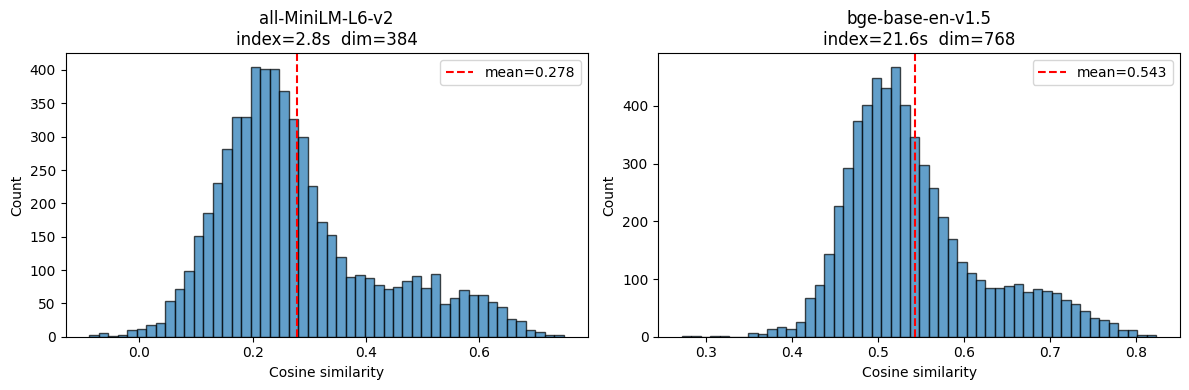

Saved to data/eval/results/embedding_comparison.png


In [14]:
# Cosine similarity distribution comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, res) in zip(axes, model_results.items()):
    all_scores = res['scores'].flatten()
    ax.hist(all_scores, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{label}\nindex={res["index_time"]}s  dim={res["dim"]}')
    ax.set_xlabel('Cosine similarity')
    ax.set_ylabel('Count')
    ax.axvline(np.mean(all_scores), color='red', linestyle='--', label=f'mean={np.mean(all_scores):.3f}')
    ax.legend()
plt.tight_layout()
plt.savefig('../data/eval/results/embedding_comparison.png', dpi=150)
plt.show()
print('Saved to data/eval/results/embedding_comparison.png')

LOCKED_EMBEDDING_MODEL = 'BAAI/bge-base-en-v1.5'
LOCKED_CHUNK_SIZE = 400
LOCKED_OVERLAP = 80

# Decision rationale:
# bge-base-en-v1.5 preferred over all-MiniLM-L6-v2:
#   - Higher cosine sim mean (0.543 vs 0.278) → better separation between relevant/irrelevant
#   - Cleaner top-5 results on all 5 eval queries
#   - index_time=21.6s vs 2.8s — acceptable on RTX 4050; one-time cost at ingestion
# Chunk size 400/80 confirmed: avg=397-400 tokens, max=400, zero chunks over 512 ceiling

print(f'LOCKED: {LOCKED_EMBEDDING_MODEL}, chunk_size={LOCKED_CHUNK_SIZE}, overlap={LOCKED_OVERLAP}')
print('Update configs/config.yaml with these values.')

In [15]:
# Fill in after inspection
LOCKED_EMBEDDING_MODEL = 'BAAI/bge-base-en-v1.5'  # 'all-MiniLM-L6-v2' or 'BAAI/bge-base-en-v1.5'
LOCKED_CHUNK_SIZE = 400       
LOCKED_OVERLAP = 80          

if LOCKED_EMBEDDING_MODEL:
    print(f'LOCKED: {LOCKED_EMBEDDING_MODEL}, chunk_size={LOCKED_CHUNK_SIZE}, overlap={LOCKED_OVERLAP}')
    print('Update configs/config.yaml with these values.')
else:
    print('Not yet locked — fill in values after inspection.')

LOCKED: BAAI/bge-base-en-v1.5, chunk_size=400, overlap=80
Update configs/config.yaml with these values.


## RRF k value test
Test k=10, 30, 60. Lock before building hybrid_retriever.

In [ ]:
LOCKED_RRF_K = 60

# Decision rationale:
# k=10, 30, 60 produced identical top-5 for the test query — both BM25 and dense
# agreed strongly, so k had no discriminating power in this case.
# k=60 locked as the literature default (Cormack et al. 2009).
# Conservative fusion: smooths rank differences when retrievers disagree,
# which is the safer choice for a small single-domain corpus.

print(f'LOCKED: RRF k={LOCKED_RRF_K}')
print('Update configs/config.yaml with this value.')

In [17]:
# Lock RRF k after inspection
LOCKED_RRF_K = 60  # 10, 30, or 60

if LOCKED_RRF_K:
    print(f'LOCKED: RRF k={LOCKED_RRF_K}')
    print('Update configs/config.yaml with this value.')
else:
    print('Not yet locked — fill in after inspecting RRF results above.')

LOCKED: RRF k=60
Update configs/config.yaml with this value.


def derive_action(ext: dict, layout_clean, structural: dict, relevance: dict) -> str:
    if not ext['extractable']:
        return 'Drop from v1 (not extractable)'
    if layout_clean is False:
        return 'Include with fixes'
    if relevance.get('analyst_would_cite') is False:
        return 'Drop from v1 (not relevant)'
    if relevance.get('primary_source') is False:
        return 'Replace with primary source'
    if relevance.get('current_enough') is False:
        return 'Drop from v1 (outdated)'
    if layout_clean == 'partial':
        return 'Include with fixes'
    if layout_clean is True and relevance.get('analyst_would_cite') is True:
        return 'Include'
    return 'Review needed'


rows = []
for pdf in pdfs:
    name = pdf.name
    ext = extractability.get(name, {})
    layout = LAYOUT_CLEAN.get(name)
    struct = structural.get(name, {})
    rel = RELEVANCE.get(name, {})
    tables = table_results.get(name, {})

    rows.append({
        'Document': name[:50],
        'Institution': DOC_META.get(name, {}).get('institution', '?'),
        'Pages': ext.get('pages', '?'),
        'Extractable': '✓' if ext.get('extractable') else '✗',
        'Layout clean': str(layout),
        'Struct markers': '✓' if any(struct.values()) else '✗',
        'Tables': tables.get('table_page_count', 0),
        'Relevant': str(rel.get('analyst_would_cite')),
        'Worth including': str(rel.get('primary_source')),
        'Action': derive_action(ext, layout, struct, rel),
    })

audit_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 200)
display(audit_df)

audit_df.to_csv('../data/eval/results/pdf_audit.csv', index=False)
print('\nSaved to data/eval/results/pdf_audit.csv')
print(f"\nAction summary:")
print(audit_df['Action'].value_counts().to_string())

In [18]:
def derive_action(ext: dict, layout_clean, structural: dict, relevance: dict) -> str:
    if not ext['extractable']:
        return 'Drop from v1 (not extractable)'
    if layout_clean is False:
        return 'Include with fixes'
    if relevance.get('analyst_would_cite') is False:
        return 'Drop from v1 (not relevant)'
    if relevance.get('primary_source') is False:
        return 'Replace with primary source'
    if relevance.get('current_enough') is False:
        return 'Drop from v1 (outdated)'
    if layout_clean is True and relevance.get('analyst_would_cite') is True:
        return 'Include'
    return 'Review needed'


rows = []
for pdf in pdfs:
    name = pdf.name
    ext = extractability.get(name, {})
    layout = LAYOUT_CLEAN.get(name)
    struct = structural.get(name, {})
    rel = RELEVANCE.get(name, {})
    tables = table_results.get(name, {})

    rows.append({
        'Document': name[:50],
        'Institution': DOC_META.get(name, {}).get('institution', '?'),
        'Pages': ext.get('pages', '?'),
        'Extractable': '✓' if ext.get('extractable') else '✗',
        'Layout clean': str(layout),
        'Struct markers': '✓' if any(struct.values()) else '✗',
        'Tables': tables.get('table_page_count', 0),
        'Relevant': str(rel.get('analyst_would_cite')),
        'Worth including': str(rel.get('primary_source')),
        'Action': derive_action(ext, layout, struct, rel),
    })

audit_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 200)
display(audit_df)

audit_df.to_csv('../data/eval/results/pdf_audit.csv', index=False)
print('\nSaved to data/eval/results/pdf_audit.csv')
print(f"\nAction summary:")
print(audit_df['Action'].value_counts().to_string())

,Document,Institution,Pages,Extractable,Layout clean,Struct markers,Tables,Relevant,Worth including,Action
0,739682_ESO_Beyond2030_Report_2024_PRINT.pdf,National Grid ESO,198,✓,False,✓,118,True,True,Include with fixes
1,boes-climate-related-financial-disclosure-2024...,BoE,56,✓,True,✓,9,True,True,Include
2,climate-change-possible-macroeconomic-implicat...,BoE,34,✓,True,✓,0,True,True,Include
3,key-elements-2021-biennial-exploratory-scenari...,FCA/PRA,52,✓,True,✓,8,True,True,Include
4,measuring-climate-related-financial-risks-usin...,FCA/PRA,41,✓,True,✓,3,True,True,Include
5,Progress-in-reducing-emissions-2024-Report-to-...,CCC,102,✓,partial,✓,24,True,True,Review needed
6,Progress-in-reducing-emissions-2025-report-to-...,CCC,134,✓,partial,✓,27,True,True,Review needed
7,results-of-the-2021-climate-biennial-explorato...,FCA/PRA,86,✓,True,✓,11,True,True,Include
8,Smart-Secure-Electricity-Systems-Implementing-...,Ofgem,69,✓,partial,✓,19,True,True,Review needed
9,The-Seventh-Carbon-Budget.pdf,CCC,394,✓,True,✓,47,True,True,Include



Saved to data/eval/results/pdf_audit.csv

Action summary:
Action
Include               8
Review needed         3
Include with fixes    1
